In [1]:
%pip install -q tensorflow scikit-learn pandas matplotlib seaborn

In [2]:
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
VOCAB_SIZE = 10000
MAX_LENGTH = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE,
    seed=SEED
)

print("Training reviews:", len(x_train))
print("Testing reviews:", len(x_test))
print("First review (encoded):", x_train[0][:20])
print("First sentiment:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training reviews: 25000
Testing reviews: 25000
First review (encoded): [1, 11, 4079, 11, 4, 1986, 745, 3304, 299, 1206, 590, 3029, 1042, 37, 47, 27, 1269, 2, 7637, 19]
First sentiment: 1


In [4]:
word_index = imdb.get_word_index()

reverse_word_index = {
    index + 3: word
    for word, index in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<OOV>"

def decode_review(sequence):
    return " ".join(
        reverse_word_index.get(int(token), "<OOV>")
        for token in sequence
    )

sample_review = decode_review(x_train[0])

print("Decoded review:")
print(sample_review[:1000])

print("\nSentiment:",
      "Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Decoded review:
<START> in panic in the streets richard widmark plays u s navy doctor who has his week <OOV> interrupted with a corpse that contains plague as cop paul douglas properly points out the guy died from two bullets in the chest that's not the issue here the two of them become unwilling partners in an effort to find the killers and anyone else exposed to the disease br br as was pointed out by any number of people for some reason director <OOV> kazan did not bother to cast the small parts with anyone that sounds like they're from <OOV> having been to new orleans where the story takes place i can personally <OOV> to that richard widmark and his wife barbara <OOV> <OOV> can be <OOV> because as a navy doctor he could be assigned there but for those that are natives it doesn't work br br but with plague out there and the news being kept a secret the new orleans <OOV> starts a <OOV> of the city's underworld the dead guy came off a s

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_sample = clean_text(sample_review)

print("Original decoded text:\n", sample_review[:300])
print("\nCleaned text:\n", cleaned_sample[:300])

Original decoded text:
 <START> in panic in the streets richard widmark plays u s navy doctor who has his week <OOV> interrupted with a corpse that contains plague as cop paul douglas properly points out the guy died from two bullets in the chest that's not the issue here the two of them become unwilling partners in an eff

Cleaned text:
 in panic in the streets richard widmark plays u s navy doctor who has his week interrupted with a corpse that contains plague as cop paul douglas properly points out the guy died from two bullets in the chest that's not the issue here the two of them become unwilling partners in an effort to find th


In [6]:
x_train_pad = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post",
    value=0
)

x_test_pad = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post",
    value=0
)

y_train = np.asarray(y_train, dtype="float32")
y_test = np.asarray(y_test, dtype="float32")

print("Training input shape:", x_train_pad.shape)
print("Testing input shape:", x_test_pad.shape)

Training input shape: (25000, 200)
Testing input shape: (25000, 200)


In [7]:
EMBEDDING_DIM = 64
HIDDEN_UNITS = 64

def build_model(model_type):
    model = Sequential()

    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ))

    if model_type == "RNN":
        model.add(SimpleRNN(HIDDEN_UNITS))

    elif model_type == "LSTM":
        model.add(LSTM(HIDDEN_UNITS))

    elif model_type == "GRU":
        model.add(GRU(HIDDEN_UNITS))

    model.add(Dropout(0.3))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
EPOCHS = 5
BATCH_SIZE = 128

models = {}
histories = {}
training_times = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type} model...")

    tf.keras.backend.clear_session()
    model = build_model(model_type)

    start_time = time.perf_counter()

    history = model.fit(
        x_train_pad,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        shuffle=True,
        verbose=1
    )

    elapsed = time.perf_counter() - start_time

    models[model_type] = model
    histories[model_type] = history
    training_times[model_type] = elapsed

    print(f"{model_type} training time: {elapsed:.2f} seconds")


Training RNN model...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.7095 - loss: 0.5545 - val_accuracy: 0.8076 - val_loss: 0.4360
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8630 - loss: 0.3457 - val_accuracy: 0.8262 - val_loss: 0.4142
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8924 - loss: 0.2790 - val_accuracy: 0.8226 - val_loss: 0.4361
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9143 - loss: 0.2269 - val_accuracy: 0.8390 - val_loss: 0.4731
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9093 - loss: 0.2298 - val_accuracy: 0.8086 - val_loss: 0.5421
RNN training time: 38.41 seconds

Training LSTM model...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7414 - loss: 0.5130 - val_accuracy: 0.8496 - val_loss: 0.3713
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8808 - loss: 0.3068 - val_accuracy: 0.8490 - val_loss: 0.4051
Epoch 3/5
157/157 ━━━

In [11]:
results = []

for model_type, model in models.items():
    probabilities = model.predict(
        x_test_pad,
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()

    predictions = (probabilities >= 0.5).astype(int)

    results.append({
        "Model": model_type,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "Training Time (seconds)": training_times[model_type]
    })

results_df = pd.DataFrame(results)

print(results_df.round(4).to_string(index=False))

Model  Accuracy  Precision  Recall  F1-score  Training Time (seconds)
  RNN    0.7958     0.7644  0.8551    0.8072                  38.4055
 LSTM    0.8158     0.7964  0.8486    0.8216                  27.6845
  GRU    0.8314     0.8850  0.7617    0.8187                  13.3127


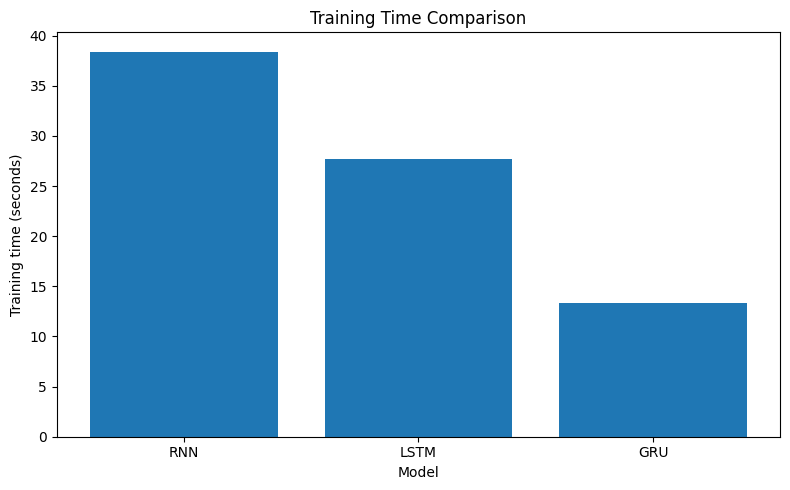

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Training Time (seconds)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training time (seconds)")
plt.tight_layout()
plt.show()


==================== RNN ====================
              precision    recall  f1-score   support

    Negative       0.84      0.74      0.78     12500
    Positive       0.76      0.86      0.81     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000



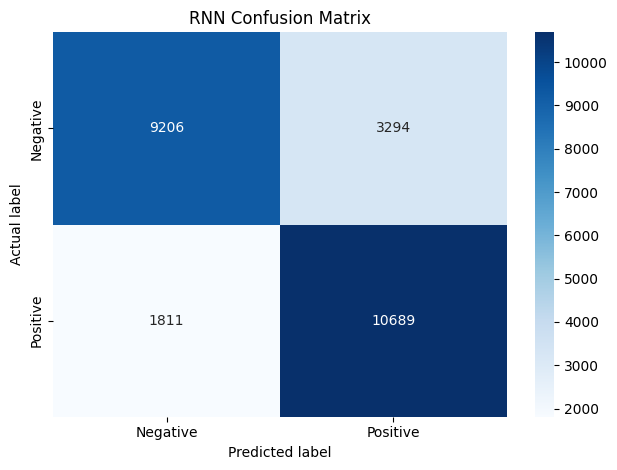


==================== LSTM ====================
              precision    recall  f1-score   support

    Negative       0.84      0.78      0.81     12500
    Positive       0.80      0.85      0.82     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



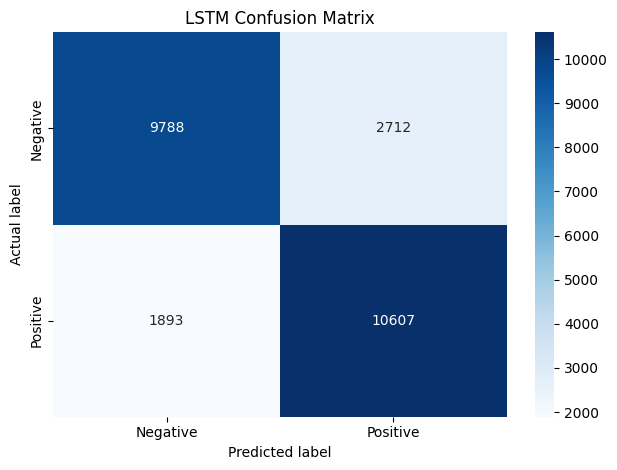


==================== GRU ====================
              precision    recall  f1-score   support

    Negative       0.79      0.90      0.84     12500
    Positive       0.89      0.76      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



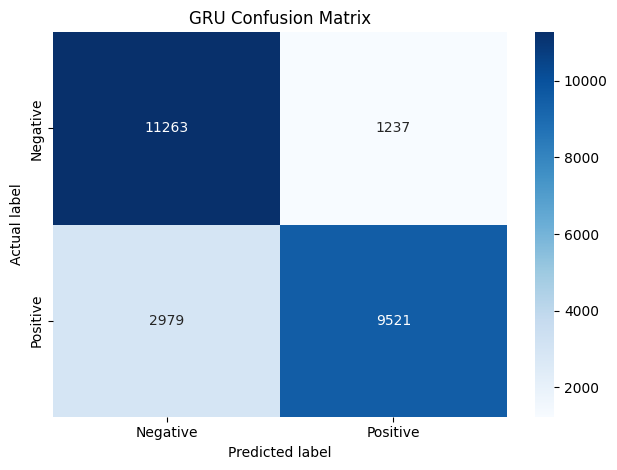

In [13]:
for model_type, model in models.items():
    probabilities = model.predict(
        x_test_pad,
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()

    predictions = (probabilities >= 0.5).astype(int)

    print(f"\n{'=' * 20} {model_type} {'=' * 20}")

    print(classification_report(
        y_test,
        predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.title(f"{model_type} Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.tight_layout()
    plt.show()

In [14]:
results_df.to_csv(
    "sentiment_model_comparison.csv",
    index=False
)

results_df.to_excel(
    "sentiment_model_comparison.xlsx",
    index=False
)

print("Comparison files saved successfully.")

Comparison files saved successfully.


In [15]:
for model_type, model in models.items():
    model.save(f"{model_type.lower()}_sentiment_model.keras")

print("All three models saved.")

All three models saved.
